# 1 Packages <a class="anchor" id="chapter1"></a>
jump to [table of content](#chapter0)

In [1]:
from scipy.stats import norm
#from configuration import *
#from qm import SimulationConfig
#from tools import *
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.stats import norm
from scipy import interpolate
from scipy.optimize import minimize
from time import time
from scipy.optimize import curve_fit
import scipy.constants as cs
from datetime import datetime
from scipy.io import savemat, loadmat
#import pyvisa as visa
import os
import shutil
#import Lorentz_fit as Lorentz
import json
import glob
from tabulate import tabulate
from scipy.optimize import fsolve
import matplotlib.image as mpimg
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
%matplotlib notebook

def fitRabi(t, A0, tau2, omega, phi, B0):
    return A0*np.exp(-t/tau2)*np.sin(omega*t + phi) + B0
def GammaThermalShotnoise(ktot, chi, nth): #From Rigetti paper, kappa with Amplitude decay
    #Superconducting qubit in a waveguide cavity with a coherence time approaching 0.1 ms
    #Using a qubit to measure photon-number statistics of a driven thermal oscillator
    return ktot/2 * np.real((np.sqrt((1+2*1j*chi/ktot)**2 + (8j * chi * nth / ktot))-1))
    #return ktot/2 * np.real((np.sqrt((1+2*1j*chi/ktot)**2 + (8j * chi * nth / ktot))-1))
    #return (1+2*1j*chi/ktot)**2 + (8j * chi * nth / ktot)
def GammaThermalShotnoiseSimple(ktot, chi, nth): #From Rigetti paper, kappa with Amplitude decay
    #Using a qubit to measure photon-number statistics of a driven thermal oscillator
    return ktot * chi**2/(ktot**2/4+chi**2)*nth
def GammaThermalShotnoise2(ktot, nth, N): #From Schoelkopf paper
    #N is the photon peak at frequency wq - N*chi
    #Photon shot noise dephasing in the strong-dispersive limit of circuit QED
    return ktot * ((nth + 1)*N + nth*(N + 1))
#Assume a (also decaying possible) cavity population and compare the increased decay to the T2 Echo
def T2Shotnoise(t, delta, ktot, chi, n, T2Echo, phi): #From Gambetta paper
    #Rapid Driven Reset of a Qubit Readout Resonator
    tau = (1-np.exp(-(ktot + 2j*chi)*t))/(ktot + 2j*chi)
    return 1/2*(1-np.imag(np.exp(-(1/T2Echo + 1j*delta)*t + (phi-2*n*chi*tau)*1j)))
#Cavity induced Ramsey oscillations
def T2Coh(t,chi,T2, n): # from Appendix E3 of Number-Resolved Photocounter for Propagating Microwave Mode R.
    return np.cos(n * np.sin(chi*t)) * np.exp( n * (np.cos(chi*t)-1)-t/T2)
def T2Thermal(t,chi,T2, nth): # from Appendix B1 of Dissipative Stabilization of Squeezing beyond 3 dB in a Microwave Mode
    #nth of the cavity
    return (nth*(1-np.cos(chi * t)) + 1) / (2*(1-np.cos(chi*t))*(nth+1)+1)*np.exp(-t/T2)
def BoseEinstein(f,T):
    return 1/(np.exp(cs.h*f/(cs.k*T))-1)
def Tphi(T1,T2):#this is valid if T1 and T2 have an exponential decay (T2 limited by 2T1 and e.g. white photon shot noise)
    #(1/f noise and several noise sources in general make a Gaussian noise statistics, so you have
    #T2 ~ exp(-t/2T1)*exp(-t**2/Tphi**2))
    return 1/(1/T2-1/(2*T1))
def TphiTrab(T1,Trab):
    return 1/(2/Trab-3/(2*T1))
def gammatotal(T1,Tphi):
    return 0.5*(1/T1+2/Tphi)
def BoseEinsteinInverse(f,n):
    return cs.h*f/(cs.k*np.log(1/n+1))
def thermaldist(nmean, N):
    return nmean**N / (nmean+1)**(N+1)
def Poissondist(nmean,N):
    return np.exp(-nmean)*nmean**N / np.fact(N)

def powerlaw(x,a,b,c):
    return a*x**b+c

def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)

def bimodal(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)

def _false_detections(threshold, Ig, Ie):
    if np.mean(Ig) < np.mean(Ie):
        false_detections_var = np.sum(Ig > threshold) + np.sum(Ie < threshold)
    else:
        false_detections_var = np.sum(Ig < threshold) + np.sum(Ie > threshold)
    return false_detections_var

In [2]:
def _false_detections(threshold, Ig, Ie):
    if np.mean(Ig) < np.mean(Ie):
        false_detections_var = np.sum(Ig > threshold) + np.sum(Ie < threshold)
    else:
        false_detections_var = np.sum(Ig < threshold) + np.sum(Ie > threshold)
    return false_detections_var


def two_state_discriminator(Ig, Qg, Ie, Qe, b_print=True, b_plot=True):
    
# Obtained and slightly modified from
# https://github.com/qua-platform/py-qua-tools/blob/main/qualang_tools/analysis/discriminator.py
    """
    Given two blobs in the IQ plane representing two states, finds the optimal threshold to discriminate between them
    and calculates the fidelity. Also returns the angle in which the data needs to be rotated in order to have all the
    information in the `I` (`X`) axis.
    .. note::
        This function assumes that there are only two blobs in the IQ plane representing two states (ground and excited)
        Unexpected output will be returned in other cases.
    :param float Ig: A vector containing the `I` quadrature of data points in the ground state
    :param float Qg: A vector containing the `Q` quadrature of data points in the ground state
    :param float Ie: A vector containing the `I` quadrature of data points in the excited state
    :param float Qe: A vector containing the `Q` quadrature of data points in the excited state
    :param bool b_print: When true (default), prints the results to the console.
    :param bool b_plot: When true (default), plots the results in a new figure.
    :returns: A tuple of (angle, threshold, fidelity, gg, ge, eg, ee).
        angle - The angle (in radians) in which the IQ plane has to be rotated in order to have all the information in
            the `I` axis.
        threshold - The threshold in the rotated `I` axis. The excited state will be when the `I` is larger (>) than
            the threshold.
        fidelity - The fidelity for discriminating the states.
        gg - The matrix element indicating a state prepared in the ground state and measured in the ground state.
        ge - The matrix element indicating a state prepared in the ground state and measured in the excited state.
        eg - The matrix element indicating a state prepared in the excited state and measured in the ground state.
        ee - The matrix element indicating a state prepared in the excited state and measured in the excited state.
    """
    # Condition to have the Q equal for both states:
    angle = np.arctan2(np.mean(Qe) - np.mean(Qg), np.mean(Ig) - np.mean(Ie))
    C = np.cos(angle)
    S = np.sin(angle)
    # Condition for having e > Ig
    if np.mean((Ig - Ie) * C - (Qg - Qe) * S) > 0:
        angle += np.pi
        C = np.cos(angle)
        S = np.sin(angle)

    Ig_rotated = Ig * C - Qg * S
    Qg_rotated = Ig * S + Qg * C

    Ie_rotated = Ie * C - Qe * S
    Qe_rotated = Ie * S + Qe * C

    fit = minimize(
        _false_detections,
        0.5 * (np.mean(Ig_rotated) + np.mean(Ie_rotated)),
        (Ig_rotated, Ie_rotated),
        method="Nelder-Mead",
    )
    threshold = fit.x[0]

    gg = np.sum(Ig_rotated < threshold) / len(Ig_rotated)
    ge = np.sum(Ig_rotated > threshold) / len(Ig_rotated)
    eg = np.sum(Ie_rotated < threshold) / len(Ie_rotated)
    ee = np.sum(Ie_rotated > threshold) / len(Ie_rotated)

    fidelity = 100 * (gg + ee) / 2

    if b_print:
        print(
            f"""
        Fidelity Matrix:
        -----------------
        | {gg:.3f} | {ge:.3f} |
        ----------------
        | {eg:.3f} | {ee:.3f} |
        -----------------
        IQ plane rotated by: {180 / np.pi * angle:.1f}{chr(176)}
        Threshold: {threshold:.3e}
        Fidelity: {fidelity:.2f}%
        """
        )

    if b_plot:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)
        ax1.plot(Ig, Qg, ".", alpha=0.1, label="Ground", markersize=2)
        ax1.plot(Ie, Qe, ".", alpha=0.1, label="Excited", markersize=2)
        ax1.axis("equal")
        ax1.legend(["Ground", "Excited"])
        ax1.set_xlabel("I")
        ax1.set_ylabel("Q")
        ax1.set_title("Original Data")

        ax2.plot(Ig_rotated, Qg_rotated, ".", alpha=0.1, label="Ground", markersize=2)
        ax2.plot(Ie_rotated, Qe_rotated, ".", alpha=0.1, label="Excited", markersize=2)
        ax2.axis("equal")
        ax2.set_xlabel("I")
        ax2.set_ylabel("Q")
        ax2.set_title("Rotated Data")

        ax3.hist(Ig_rotated, bins=50, alpha=0.75, label="Ground")
        ax3.hist(Ie_rotated, bins=50, alpha=0.75, label="Excited")
        ax3.axvline(x=threshold, color="k", ls="--", alpha=0.5)
        text_props = dict(
            horizontalalignment="center",
            verticalalignment="center",
            transform=ax3.transAxes,
        )
        ax3.text(0.7, 0.9, f"{threshold:.3e}", text_props)
        ax3.set_xlabel("I")
        ax3.set_title("1D Histogram")

        ax4.imshow(np.array([[gg, ge], [eg, ee]]))
        ax4.set_xticks([0, 1])
        ax4.set_yticks([0, 1])
        ax4.set_xticklabels(labels=["|g>", "|e>"])
        ax4.set_yticklabels(labels=["|g>", "|e>"])
        ax4.set_ylabel("Prepared")
        ax4.set_xlabel("Measured")
        ax4.text(0, 0, f"{100 * gg:.1f}%", ha="center", va="center", color="k")
        ax4.text(1, 0, f"{100 * ge:.1f}%", ha="center", va="center", color="w")
        ax4.text(0, 1, f"{100 * eg:.1f}%", ha="center", va="center", color="w")
        ax4.text(1, 1, f"{100 * ee:.1f}%", ha="center", va="center", color="k")
        ax4.set_title("Fidelities")
        fig.tight_layout()

    return angle, threshold, fidelity, gg, ge, eg, ee, fit

# 2 Import data <a class="anchor" id="chapter2"></a>
jump to [table of content](#chapter0)

In [3]:
import shutil

folder = '.\\Fig_4a\\'

## Optics on during state preparation and readout
file0Hz_prep = 'IQblobs_0Hz_prep.mat'
file10Hz_prep = 'IQblobs_10Hz_prep.mat'
file50Hz_prep = 'IQblobs_50Hz_prep.mat'
file250Hz_prep = 'IQblobs_250Hz_prep.mat'
file500Hz_prep = 'IQblobs_500Hz_prep.mat'
file1000Hz_prep = 'IQblobs_1000Hz_prep.mat'

filename = folder + file1000Hz_prep


## Optics on only during readout
file0Hz = 'IQblobs_0Hz.mat'
file10Hz = 'IQblobs_10Hz.mat'
file50Hz = 'IQblobs_50Hz.mat'
file250Hz = 'IQblobs_250Hz.mat'
file500Hz = 'IQblobs_500Hz.mat'
file1000Hz = 'IQblobs_1000Hz.mat'

filename = folder + file1000Hz


mdict = loadmat(filename)

In [4]:
Ig = mdict['I_g'][0]
Qg = mdict['Q_g'][0]
Ie = mdict['I_e'][0]
Qe = mdict['Q_e'][0]

Ig2 = mdict['I_g2'][0]
Qg2 = mdict['Q_g2'][0]
Ie2 = mdict['I_e2'][0]
Qe2 = mdict['Q_e2'][0]

n_runs = 50000


        Fidelity Matrix:
        -----------------
        | 0.800 | 0.200 |
        ----------------
        | 0.280 | 0.720 |
        -----------------
        IQ plane rotated by: 172.0°
        Threshold: -7.921e-06
        Fidelity: 76.02%
        


<IPython.core.display.Javascript object>


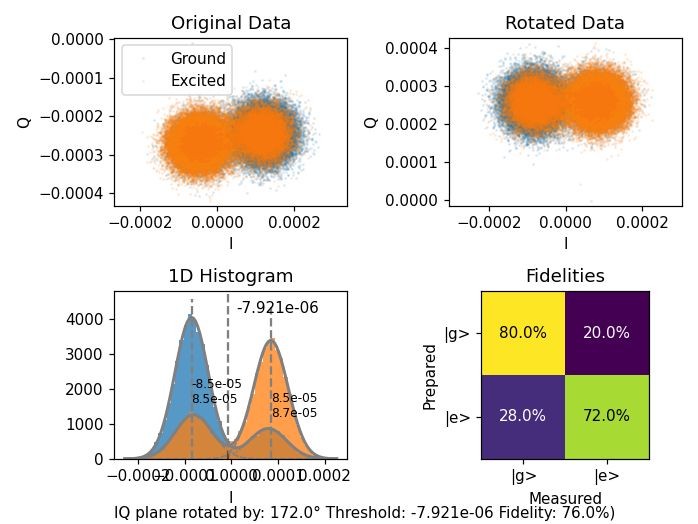

gstate: Center,FWHM,maxI,Center2,FWHM2,maxI2
[ 7.88883124e-05  9.30639854e-05  8.70334726e+02 -8.52974147e-05
  8.45397020e-05  4.05604146e+03]
estate: Center,FWHM,maxI,Center2,FWHM2,maxI2
[ 8.47336682e-05  8.66698106e-05  3.39685871e+03 -8.08257707e-05
  9.38765460e-05  1.26782105e+03]

        Fidelity Matrix:
        -----------------
        | 0.795 | 0.205 |
        ----------------
        | 0.361 | 0.639 |
        -----------------
        IQ plane rotated by: 171.4°
        Threshold: -3.686e-06
        Fidelity: 71.68%
        


<IPython.core.display.Javascript object>


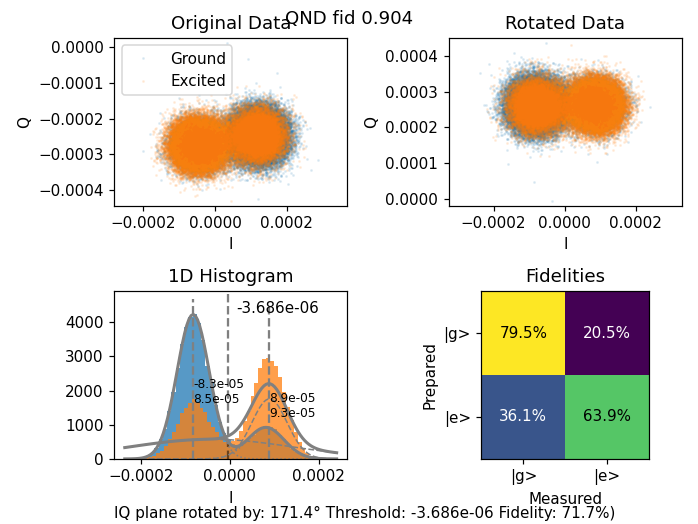

QND: 0.9040222861087042


In [5]:
angle, threshold, fidelity, gg, ge, eg, ee, fit = two_state_discriminator(Ig, Qg, Ie, Qe, b_print=True, b_plot=True)

f = plt.gcf()
a = f.axes[2]
a.text(0.0,-0.35,
         f"""IQ plane rotated by: {180 / np.pi * angle:.1f}{chr(176)} Threshold: {threshold:.3e} Fidelity: {fidelity:.1f}%)"""
         , size = '10', transform = a.transAxes)

C = np.cos(angle)
S = np.sin(angle)
Ig_rotated = Ig * C - Qg * S
Qg_rotated = Ig * S + Qg * C

Ie_rotated = Ie * C - Qe * S
Qe_rotated = Ie * S + Qe * C

c_g,bins_g = np.histogram(Ig_rotated, bins = 50)
c_e,bins_e = np.histogram(Ie_rotated, bins = 50)

#If the peaks are distorted, it's best to just take the max of the histogram
I_max_g = bins_g[np.argmax(c_g)]
I_max_e = bins_e[np.argmax(c_e)]

Idff = abs(I_max_g - I_max_e)

FWHM_e =  2*abs(I_max_e-bins_e[np.argmin(abs(np.max(c_e)/2-c_e[:np.argmax(c_e)]))])
FWHM_g =  2*abs(I_max_g-bins_e[np.argmin(abs(np.max(c_g)/2-c_g[:np.argmax(c_g)]))])

expected_e = (I_max_e,FWHM_e/np.sqrt(8*np.log(2)),np.max(c_e),I_max_g,FWHM_e,np.max(c_e)/10)
expected_g = (I_max_e,FWHM_g/np.sqrt(8*np.log(2)),np.max(c_g)/10,I_max_g,FWHM_g,np.max(c_g))
params_e, cov_e = curve_fit(bimodal, (bins_e[1:]+bins_e[:-1])/2, c_e, expected_e
    , bounds = ([I_max_e-Idff/4.,0,0, I_max_g-Idff/4., 0, 0],[I_max_e+Idff/4., np.inf, np.inf, I_max_g+Idff/4., np.inf, np.inf]))
params_g, cov_g = curve_fit(bimodal, (bins_g[1:]+bins_g[:-1])/2, c_g, expected_g
    , bounds = ([I_max_e-Idff/4.,0,0, I_max_g-Idff/4., 0, 0],[I_max_e+Idff/4., np.inf, np.inf, I_max_g+Idff/4., np.inf, np.inf]))
x_fit = np.linspace(np.min([bins_e, bins_g]), np.max([bins_e, bins_g]), 100)

print('gstate: Center,FWHM,maxI,Center2,FWHM2,maxI2')
print(params_g*np.array([1,np.sqrt(8*np.log(2)),1,1,np.sqrt(8*np.log(2)),1]))
print('estate: Center,FWHM,maxI,Center2,FWHM2,maxI2')
print(params_e*np.array([1,np.sqrt(8*np.log(2)),1,1,np.sqrt(8*np.log(2)),1]))
#plot combined...
a.plot(x_fit, bimodal(x_fit, *params_e), color='gray', lw=2, label='model')
a.plot(x_fit, bimodal(x_fit, *params_g), color='gray', lw=2, label='model')
#...and individual Gauss curves
a.plot(x_fit, gauss(x_fit, *params_e[:3]), color='gray', lw=1, ls="--", label='distribution 1')
a.plot(x_fit, gauss(x_fit, *params_e[3:]), color='gray', lw=1, ls="--", label='distribution 2')
a.plot(x_fit, gauss(x_fit, *params_g[:3]), color='gray', lw=1, ls=":", label='distribution 1')
a.plot(x_fit, gauss(x_fit, *params_g[3:]), color='gray', lw=1, ls=":", label='distribution 2')

a.vlines(params_e[0], np.min(0), a.get_ylim()[1], color = "grey", linestyle = 'dashed')
a.vlines(params_g[3], np.min(0), a.get_ylim()[1], color = 'grey', linestyle = 'dashed')
a.text(params_e[0],a.get_ylim()[1]/4,str(np.round(params_e[0],6))+'\n'+str(np.round(params_e[1]*np.sqrt(8*np.log(2)),6)), size = '8')
a.text(params_g[3],a.get_ylim()[1]/3,str(np.round(params_g[3],6))+'\n'+str(np.round(params_g[4]*np.sqrt(8*np.log(2)),6)), size = '8')
plt.show() 
# plt.savefig(filename.replace('.mat', '0.png'))    
    
angle2, threshold2, fidelity2, gg2, ge2, eg2, ee2, fit = two_state_discriminator(Ig2, Qg2, Ie2, Qe2, b_print=True, b_plot=True)


f = plt.gcf()
a = f.axes[2]
a.text(0.0,-0.35,
         f"""IQ plane rotated by: {180 / np.pi * angle2:.1f}{chr(176)} Threshold: {threshold2:.3e} Fidelity: {fidelity2:.1f}%)"""
         , size = '10', transform = a.transAxes)
# a.text(0.0,1.15, 
#           qubitoperation + 'pulse ' + str(np.round(qubitpulseAmp,3)) + 'V ' + str(qubitpulseLen) + 'ns ' 
#           + readouttype + 'pulse ' + str(np.round(readoutAmp*prefactor,3)) + 'V ' + str(readoutLen) + 'ns_IF'
#        + str(resonatorfreq/1e6) + 'MHz'
#       , size = '10', transform = a.transAxes)
C = np.cos(angle2)
S = np.sin(angle2)
Ig2_rotated = Ig2 * C - Qg2 * S
Qg2_rotated = Ig2 * S + Qg2 * C

Ie2_rotated = Ie2 * C - Qe2 * S
Qe2_rotated = Ie2 * S + Qe2 * C

c_g2,bins_g2 = np.histogram(Ig2_rotated, bins = 50)
c_e2,bins_e2 = np.histogram(Ie2_rotated, bins = 50)

#If the peaks are distorted, it's best to just take the max of the histogram
I_max_g2 = bins_g[np.argmax(c_g2)]
I_max_e2 = bins_e[np.argmax(c_e2)]

Idff2 = abs(I_max_g2 - I_max_e2)

FWHM_e2 =  2*abs(I_max_e2-bins_e2[np.argmin(abs(np.max(c_e2)/2-c_e2[:np.argmax(c_e2)]))])
FWHM_g2 =  2*abs(I_max_g2-bins_e2[np.argmin(abs(np.max(c_g2)/2-c_g2[:np.argmax(c_g2)]))])

expected_e2 = (I_max_e2,FWHM_e2/np.sqrt(8*np.log(2)),np.max(c_e2),I_max_g2,FWHM_e2,np.max(c_e2)/10)
expected_g2 = (I_max_e2,FWHM_g2/np.sqrt(8*np.log(2)),np.max(c_g2)/10,I_max_g2,FWHM_g2,np.max(c_g2))
params_e2, cov_e2 = curve_fit(bimodal, (bins_e2[1:]+bins_e2[:-1])/2, c_e2, expected_e2
    , bounds = ([I_max_e2-Idff2/4.,0,0, I_max_g2-Idff2/4., 0, 0],[I_max_e2+Idff2/4., np.inf, np.inf, I_max_g2+Idff2/4., np.inf, np.inf]))
params_g2, cov_g2 = curve_fit(bimodal, (bins_g2[1:]+bins_g2[:-1])/2, c_g2, expected_g2
    , bounds = ([I_max_e2-Idff2/4.,0,0, I_max_g2-Idff2/4., 0, 0],[I_max_e2+Idff2/4., np.inf, np.inf, I_max_g2+Idff2/4., np.inf, np.inf]))
x_fit2 = np.linspace(np.min([bins_e2, bins_g2]), np.max([bins_e2, bins_g2]), 100)

# print('gstate2: Center,FWHM,maxI,Center2,FWHM2,maxI2')
# print(params_g2*np.array([1,np.sqrt(8*np.log(2)),1,1,np.sqrt(8*np.log(2)),1]))
# print('estate2: Center,FWHM,maxI,Center2,FWHM2,maxI2')
# print(params_e2*np.array([1,np.sqrt(8*np.log(2)),1,1,np.sqrt(8*np.log(2)),1]))
#plot combined...
a.plot(x_fit2, bimodal(x_fit2, *params_e2), color='gray', lw=2, label='model')
a.plot(x_fit2, bimodal(x_fit2, *params_g2), color='gray', lw=2, label='model')
#...and individual Gauss curves
a.plot(x_fit2, gauss(x_fit2, *params_e2[:3]), color='gray', lw=1, ls="--", label='distribution 1')
a.plot(x_fit2, gauss(x_fit2, *params_e2[3:]), color='gray', lw=1, ls="--", label='distribution 2')
a.plot(x_fit2, gauss(x_fit2, *params_g2[:3]), color='gray', lw=1, ls=":", label='distribution 1')
a.plot(x_fit2, gauss(x_fit2, *params_g2[3:]), color='gray', lw=1, ls=":", label='distribution 2')

a.vlines(params_e2[0], np.min(0), a.get_ylim()[1], color = "grey", linestyle = 'dashed')
a.vlines(params_g2[3], np.min(0), a.get_ylim()[1], color = 'grey', linestyle = 'dashed')
a.text(params_e2[0],a.get_ylim()[1]/4,str(np.round(params_e2[0],6))+'\n'+str(np.round(params_e2[1]*np.sqrt(8*np.log(2)),6)), size = '8')
a.text(params_g2[3],a.get_ylim()[1]/3,str(np.round(params_g2[3],6))+'\n'+str(np.round(params_g2[4]*np.sqrt(8*np.log(2)),6)), size = '8')

if np.mean(Ig_rotated)>threshold:
    Ng_g = np.sum(Ig_rotated>threshold)
    Ne_g = np.sum(Ig_rotated<threshold)
    Ng_e = np.sum(Ie_rotated>threshold)
    Ne_e = np.sum(Ie_rotated<threshold)
    Pgg = (np.sum(Ig2_rotated[Ig_rotated>threshold]>threshold2) + np.sum(Ie2_rotated[Ie_rotated>threshold]>threshold2))/(Ng_g+Ng_e)
    Pee = (np.sum(Ie2_rotated[Ie_rotated<threshold]<threshold2) + np.sum(Ig2_rotated[Ig_rotated<threshold]<threshold2))/(Ne_e+Ne_g)

else:
    Ng_g = np.sum(Ig_rotated<threshold)
    Ne_g = np.sum(Ig_rotated>threshold)
    Ng_e = np.sum(Ie_rotated<threshold)
    Ne_e = np.sum(Ie_rotated>threshold)
    Pgg = (np.sum(Ig2_rotated[Ig_rotated<threshold]<threshold2) + np.sum(Ie2_rotated[Ie_rotated<threshold]<threshold2))/(Ng_g+Ng_e)
    Pee = (np.sum(Ie2_rotated[Ie_rotated>threshold]>threshold2) + np.sum(Ig2_rotated[Ig_rotated>threshold]>threshold2))/(Ne_e+Ne_g)


QND = (Pgg+Pee)/2


print('QND: ' + str(QND))

f.suptitle('QND fid '+ str(np.round(QND,4)))
plt.show()

# Separate one set in 5 10000 measurements to estimate the statistical error

10000

        Fidelity Matrix:
        -----------------
        | 0.801 | 0.199 |
        ----------------
        | 0.278 | 0.722 |
        -----------------
        IQ plane rotated by: 171.9°
        Threshold: -7.616e-06
        Fidelity: 76.17%
        


<IPython.core.display.Javascript object>


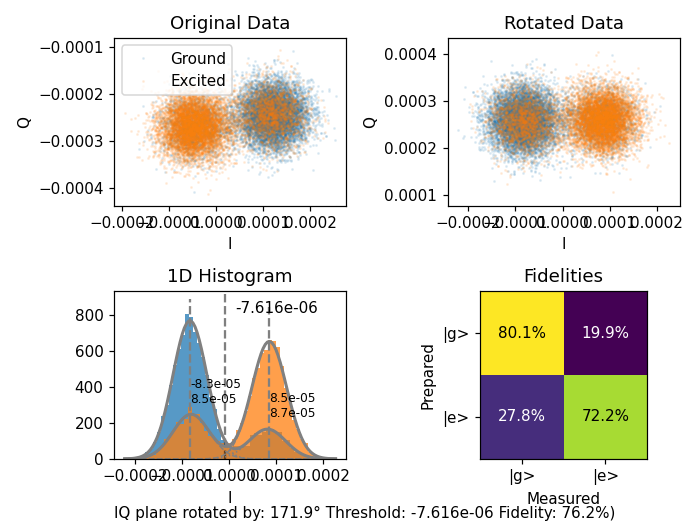

gstate: Center,FWHM,maxI,Center2,FWHM2,maxI2
[ 8.15270514e-05  9.06625235e-05  1.65628289e+02 -8.31736446e-05
  8.50364512e-05  7.69037106e+02]
estate: Center,FWHM,maxI,Center2,FWHM2,maxI2
[ 8.54426392e-05  8.71109100e-05  6.54090117e+02 -8.06829891e-05
  9.10323354e-05  2.48510503e+02]

        Fidelity Matrix:
        -----------------
        | 0.790 | 0.210 |
        ----------------
        | 0.348 | 0.652 |
        -----------------
        IQ plane rotated by: 171.4°
        Threshold: -1.166e-05
        Fidelity: 72.09%
        


<IPython.core.display.Javascript object>


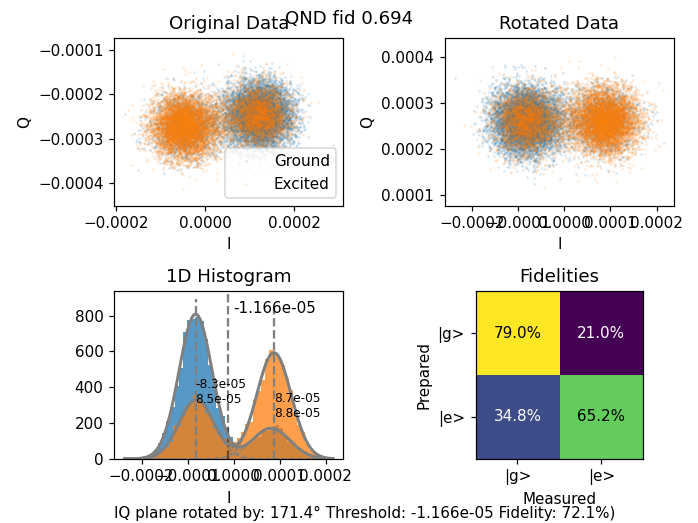

gstate2: Center,FWHM,maxI,Center2,FWHM2,maxI2
[ 8.11658120e-05  9.59381089e-05  1.71409203e+02 -8.27399291e-05
  8.46508499e-05  8.09101458e+02]
estate2: Center,FWHM,maxI,Center2,FWHM2,maxI2
[ 8.73858648e-05  8.75125128e-05  5.93967557e+02 -8.08343382e-05
  8.93653594e-05  3.31148405e+02]
0.7548
0.6338
0.6943


In [6]:
n_runs = 10000
measind = 2

Ig = mdict['I_g'][0][n_runs*measind:n_runs*(measind+1)]
Qg = mdict['Q_g'][0][n_runs*measind:n_runs*(measind+1)]
Ie = mdict['I_e'][0][n_runs*measind:n_runs*(measind+1)]
Qe = mdict['Q_e'][0][n_runs*measind:n_runs*(measind+1)]

Ig2 = mdict['I_g2'][0][n_runs*measind:n_runs*(measind+1)]
Qg2 = mdict['Q_g2'][0][n_runs*measind:n_runs*(measind+1)]
Ie2 = mdict['I_e2'][0][n_runs*measind:n_runs*(measind+1)]
Qe2 = mdict['Q_e2'][0][n_runs*measind:n_runs*(measind+1)]

print(len(Ig2))


angle, threshold, fidelity, gg, ge, eg, ee, fit = two_state_discriminator(Ig, Qg, Ie, Qe, b_print=True, b_plot=True)

f = plt.gcf()
a = f.axes[2]
a.text(0.0,-0.35,
         f"""IQ plane rotated by: {180 / np.pi * angle:.1f}{chr(176)} Threshold: {threshold:.3e} Fidelity: {fidelity:.1f}%)"""
         , size = '10', transform = a.transAxes)
# a.text(0.0,1.15, 
#           qubitoperation + 'pulse ' + str(np.round(qubitpulseAmp,3)) + 'V ' + str(qubitpulseLen) + 'ns ' 
#           + readouttype + 'pulse ' + str(np.round(readoutAmp*prefactor,3)) + 'V ' + str(readoutLen) + 'ns_IF'
#        + str(resonatorfreq/1e6) + 'MHz'
#       , size = '10', transform = a.transAxes)
C = np.cos(angle)
S = np.sin(angle)
Ig_rotated = Ig * C - Qg * S
Qg_rotated = Ig * S + Qg * C

Ie_rotated = Ie * C - Qe * S
Qe_rotated = Ie * S + Qe * C

c_g,bins_g = np.histogram(Ig_rotated, bins = 50)
c_e,bins_e = np.histogram(Ie_rotated, bins = 50)

#If the peaks are distorted, it's best to just take the max of the histogram
I_max_g = bins_g[np.argmax(c_g)]
I_max_e = bins_e[np.argmax(c_e)]

Idff = abs(I_max_g - I_max_e)

FWHM_e =  2*abs(I_max_e-bins_e[np.argmin(abs(np.max(c_e)/2-c_e[:np.argmax(c_e)]))])
FWHM_g =  2*abs(I_max_g-bins_e[np.argmin(abs(np.max(c_g)/2-c_g[:np.argmax(c_g)]))])

expected_e = (I_max_e,FWHM_e/np.sqrt(8*np.log(2)),np.max(c_e),I_max_g,FWHM_e,np.max(c_e)/10)
expected_g = (I_max_e,FWHM_g/np.sqrt(8*np.log(2)),np.max(c_g)/10,I_max_g,FWHM_g,np.max(c_g))
params_e, cov_e = curve_fit(bimodal, (bins_e[1:]+bins_e[:-1])/2, c_e, expected_e
    , bounds = ([I_max_e-Idff/4.,0,0, I_max_g-Idff/4., 0, 0],[I_max_e+Idff/4., np.inf, np.inf, I_max_g+Idff/4., np.inf, np.inf]))
params_g, cov_g = curve_fit(bimodal, (bins_g[1:]+bins_g[:-1])/2, c_g, expected_g
    , bounds = ([I_max_e-Idff/4.,0,0, I_max_g-Idff/4., 0, 0],[I_max_e+Idff/4., np.inf, np.inf, I_max_g+Idff/4., np.inf, np.inf]))
x_fit = np.linspace(np.min([bins_e, bins_g]), np.max([bins_e, bins_g]), 100)

print('gstate: Center,FWHM,maxI,Center2,FWHM2,maxI2')
print(params_g*np.array([1,np.sqrt(8*np.log(2)),1,1,np.sqrt(8*np.log(2)),1]))
print('estate: Center,FWHM,maxI,Center2,FWHM2,maxI2')
print(params_e*np.array([1,np.sqrt(8*np.log(2)),1,1,np.sqrt(8*np.log(2)),1]))
#plot combined...
a.plot(x_fit, bimodal(x_fit, *params_e), color='gray', lw=2, label='model')
a.plot(x_fit, bimodal(x_fit, *params_g), color='gray', lw=2, label='model')
#...and individual Gauss curves
a.plot(x_fit, gauss(x_fit, *params_e[:3]), color='gray', lw=1, ls="--", label='distribution 1')
a.plot(x_fit, gauss(x_fit, *params_e[3:]), color='gray', lw=1, ls="--", label='distribution 2')
a.plot(x_fit, gauss(x_fit, *params_g[:3]), color='gray', lw=1, ls=":", label='distribution 1')
a.plot(x_fit, gauss(x_fit, *params_g[3:]), color='gray', lw=1, ls=":", label='distribution 2')

a.vlines(params_e[0], np.min(0), a.get_ylim()[1], color = "grey", linestyle = 'dashed')
a.vlines(params_g[3], np.min(0), a.get_ylim()[1], color = 'grey', linestyle = 'dashed')
a.text(params_e[0],a.get_ylim()[1]/4,str(np.round(params_e[0],6))+'\n'+str(np.round(params_e[1]*np.sqrt(8*np.log(2)),6)), size = '8')
a.text(params_g[3],a.get_ylim()[1]/3,str(np.round(params_g[3],6))+'\n'+str(np.round(params_g[4]*np.sqrt(8*np.log(2)),6)), size = '8')
plt.show() 
# plt.savefig(filename.replace('.mat', 'set' + str(measind+1) + '_1.png'))    
    
angle2, threshold2, fidelity2, gg2, ge2, eg2, ee2, fit = two_state_discriminator(Ig2, Qg2, Ie2, Qe2, b_print=True, b_plot=True)


f = plt.gcf()
a = f.axes[2]
a.text(0.0,-0.35,
         f"""IQ plane rotated by: {180 / np.pi * angle2:.1f}{chr(176)} Threshold: {threshold2:.3e} Fidelity: {fidelity2:.1f}%)"""
         , size = '10', transform = a.transAxes)
# a.text(0.0,1.15, 
#           qubitoperation + 'pulse ' + str(np.round(qubitpulseAmp,3)) + 'V ' + str(qubitpulseLen) + 'ns ' 
#           + readouttype + 'pulse ' + str(np.round(readoutAmp*prefactor,3)) + 'V ' + str(readoutLen) + 'ns_IF'
#        + str(resonatorfreq/1e6) + 'MHz'
#       , size = '10', transform = a.transAxes)
C = np.cos(angle2)
S = np.sin(angle2)
Ig2_rotated = Ig2 * C - Qg2 * S
Qg2_rotated = Ig2 * S + Qg2 * C

Ie2_rotated = Ie2 * C - Qe2 * S
Qe2_rotated = Ie2 * S + Qe2 * C

c_g2,bins_g2 = np.histogram(Ig2_rotated, bins = 50)
c_e2,bins_e2 = np.histogram(Ie2_rotated, bins = 50)

#If the peaks are distorted, it's best to just take the max of the histogram
I_max_g2 = bins_g[np.argmax(c_g2)]
I_max_e2 = bins_e[np.argmax(c_e2)]

Idff2 = abs(I_max_g2 - I_max_e2)

FWHM_e2 =  2*abs(I_max_e2-bins_e2[np.argmin(abs(np.max(c_e2)/2-c_e2[:np.argmax(c_e2)]))])
FWHM_g2 =  2*abs(I_max_g2-bins_e2[np.argmin(abs(np.max(c_g2)/2-c_g2[:np.argmax(c_g2)]))])

expected_e2 = (I_max_e2,FWHM_e2/np.sqrt(8*np.log(2)),np.max(c_e2),I_max_g2,FWHM_e2,np.max(c_e2)/10)
expected_g2 = (I_max_e2,FWHM_g2/np.sqrt(8*np.log(2)),np.max(c_g2)/10,I_max_g2,FWHM_g2,np.max(c_g2))
params_e2, cov_e2 = curve_fit(bimodal, (bins_e2[1:]+bins_e2[:-1])/2, c_e2, expected_e2
    , bounds = ([I_max_e2-Idff2/4.,0,0, I_max_g2-Idff2/4., 0, 0],[I_max_e2+Idff2/4., np.inf, np.inf, I_max_g2+Idff2/4., np.inf, np.inf]))
params_g2, cov_g2 = curve_fit(bimodal, (bins_g2[1:]+bins_g2[:-1])/2, c_g2, expected_g2
    , bounds = ([I_max_e2-Idff2/4.,0,0, I_max_g2-Idff2/4., 0, 0],[I_max_e2+Idff2/4., np.inf, np.inf, I_max_g2+Idff2/4., np.inf, np.inf]))
x_fit2 = np.linspace(np.min([bins_e2, bins_g2]), np.max([bins_e2, bins_g2]), 100)

print('gstate2: Center,FWHM,maxI,Center2,FWHM2,maxI2')
print(params_g2*np.array([1,np.sqrt(8*np.log(2)),1,1,np.sqrt(8*np.log(2)),1]))
print('estate2: Center,FWHM,maxI,Center2,FWHM2,maxI2')
print(params_e2*np.array([1,np.sqrt(8*np.log(2)),1,1,np.sqrt(8*np.log(2)),1]))
#plot combined...
a.plot(x_fit2, bimodal(x_fit2, *params_e2), color='gray', lw=2, label='model')
a.plot(x_fit2, bimodal(x_fit2, *params_g2), color='gray', lw=2, label='model')
#...and individual Gauss curves
a.plot(x_fit2, gauss(x_fit2, *params_e2[:3]), color='gray', lw=1, ls="--", label='distribution 1')
a.plot(x_fit2, gauss(x_fit2, *params_e2[3:]), color='gray', lw=1, ls="--", label='distribution 2')
a.plot(x_fit2, gauss(x_fit2, *params_g2[:3]), color='gray', lw=1, ls=":", label='distribution 1')
a.plot(x_fit2, gauss(x_fit2, *params_g2[3:]), color='gray', lw=1, ls=":", label='distribution 2')

a.vlines(params_e2[0], np.min(0), a.get_ylim()[1], color = "grey", linestyle = 'dashed')
a.vlines(params_g2[3], np.min(0), a.get_ylim()[1], color = 'grey', linestyle = 'dashed')
a.text(params_e2[0],a.get_ylim()[1]/4,str(np.round(params_e2[0],6))+'\n'+str(np.round(params_e2[1]*np.sqrt(8*np.log(2)),6)), size = '8')
a.text(params_g2[3],a.get_ylim()[1]/3,str(np.round(params_g2[3],6))+'\n'+str(np.round(params_g2[4]*np.sqrt(8*np.log(2)),6)), size = '8')

if np.mean(Ig_rotated)>threshold:
    Ngg = np.sum(Ig2_rotated[Ig_rotated>threshold]>threshold2)
    Nee = np.sum(Ie2_rotated[Ie_rotated<threshold]<threshold2)
else:
    Ngg = np.sum(Ig2_rotated[Ig_rotated<threshold]<threshold2)
    Nee = np.sum(Ie2_rotated[Ie_rotated>threshold]>threshold2)
Pee = Nee/n_runs
Pgg = Ngg/n_runs
QND = (Pgg+Pee)/2
print(Pgg)
print(Pee)
print(QND)

f.suptitle('QND fid '+ str(np.round(QND,3)))
#plt.tight_layout()
plt.show() 
# plt.savefig(filename.replace('.mat', 'set' + str(measind+1) + '_2.png'))

In [7]:
print('paramse1: ' + str(params_e))
print('paramsg1: ' + str(params_g))
print('paramse2: ' + str(params_e2))
print('paramsg2: ' + str(params_g2))


print('sigmae1_1: ' + str(params_e[1]))
print('sigmae1_2: ' + str(params_e[4]))

print('sigmag1_1: ' + str(params_g[1]))
print('sigmag1_2: ' + str(params_g[4]))

print('sigmae2_1: ' + str(params_e2[1]))
print('sigmae2_2: ' + str(params_e2[4]))

print('sigmag2_1: ' + str(params_g2[1]))
print('sigmag2_2: ' + str(params_g2[4]))

paramse1: [ 8.54426392e-05  3.69925975e-05  6.54090117e+02 -8.06829891e-05
  3.86578735e-05  2.48510503e+02]
paramsg1: [ 8.15270514e-05  3.85008288e-05  1.65628289e+02 -8.31736446e-05
  3.61116559e-05  7.69037106e+02]
paramse2: [ 8.73858648e-05  3.71631425e-05  5.93967557e+02 -8.08343382e-05
  3.79499739e-05  3.31148405e+02]
paramsg2: [ 8.11658120e-05  4.07411637e-05  1.71409203e+02 -8.27399291e-05
  3.59479061e-05  8.09101458e+02]
sigmae1_1: 3.699259746822892e-05
sigmae1_2: 3.8657873511209125e-05
sigmag1_1: 3.850082882887051e-05
sigmag1_2: 3.611165590283795e-05
sigmae2_1: 3.716314245043242e-05
sigmae2_2: 3.794997394885999e-05
sigmag2_1: 4.074116370028493e-05
sigmag2_2: 3.594790609774037e-05
